# Guide for applying the star formation history and metallicity evolution determination model

In this guide, we will present a short instruction on how to correctly load the model and the data, and subsequently use the model to calculate the inferred solution. 

First, we will load the required libraries and define the folder with the data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras
import os
%matplotlib inline

model_version = "12.00.08_b"
folder_path = f"values_demo_{model_version}/"

## Loading the data

The provided data are the spectra for the given examples in Fig. 3 of [Galceran+25](https://arxiv.org/abs/2605.13973) (Figs. 3.1, 3.4, and A.1 in the thesis manuscript), i.e. IDS 8, 0, 7, and 43 of the internal numeration. For this guide, we have already sorted them in this order.

Additionally, we provide the four noise instances (SNR= 15, 20, 35, 50).

**IMPORTANT:** For a better fitting by the model, the metallicity values are scaled by a factor of 100 (This aids the Loss value by having the same order of magnitude). This needs to be undone.

In [2]:
# Load input spectra and photometry
in_phot = np.load(os.path.join(folder_path, f"input_{model_version}_phot.npy"))
in_spec = np.load(os.path.join(folder_path, f"input_{model_version}_spec.npy"))

# Load the labels
z_multiplication_factor = 100
label_sfh = np.load(os.path.join(folder_path, f"label_{model_version}_sfh.npy"))
label_z = np.load(os.path.join(folder_path, f"label_{model_version}_z.npy"))
label_z /= z_multiplication_factor

# Load vectors with centre of bin, width of bin, and limits of bins
agevec = np.load(os.path.join(folder_path, "agevec16.npy"))
agewidth = np.load(os.path.join(folder_path, "agewidth16.npy"))
agebin = np.load(os.path.join(folder_path, "agebin16.npy"))

# Initialise the spectra's wavelength and the centre of the filters
wavelength = np.arange(1761)*1.25 + 4800
wavecen = np.array([2708.680, 3358.580, 4329.475, 5331.898, 8072.917])
assert in_phot.shape[1] == wavecen.size
assert in_spec.shape[1] == wavelength.size

# Load model
model = keras.models.load_model(os.path.join(folder_path, f"model_{model_version}.h5"))
# Some loading information may appear when performing the first loading of the keras model.
# This depends on your installation of tensorflow and is normal.

print("[INFO] Finished loading.")

2026-05-19 18:00:14.254718: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-05-19 18:00:14.254736: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-19 18:00:14.254740: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-05-19 18:00:14.254768: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-19 18:00:14.254781: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


[INFO] Finished loading.


In [3]:
snr = [15, 20, 35, 50]
id_elements = [8, 0, 7, 43]
elements_per_snr = len(id_elements)

# Sort the data according to the different SNR
in_data_by_snr = dict()
label_by_snr = dict()
for i, snr_ in enumerate(snr):
    in_data_by_snr[snr_] = {
        'photometry': in_phot[(i*elements_per_snr):((i+1)*elements_per_snr), :],
        'spectra': in_spec[(i*elements_per_snr):((i+1)*elements_per_snr), :]
    }
    label_by_snr[snr_] = {
        'sfh': label_sfh[(i*elements_per_snr):((i+1)*elements_per_snr), :],
        'z': label_z[(i*elements_per_snr):((i+1)*elements_per_snr), :],
    }

Let us plot the different data and validate the noise.

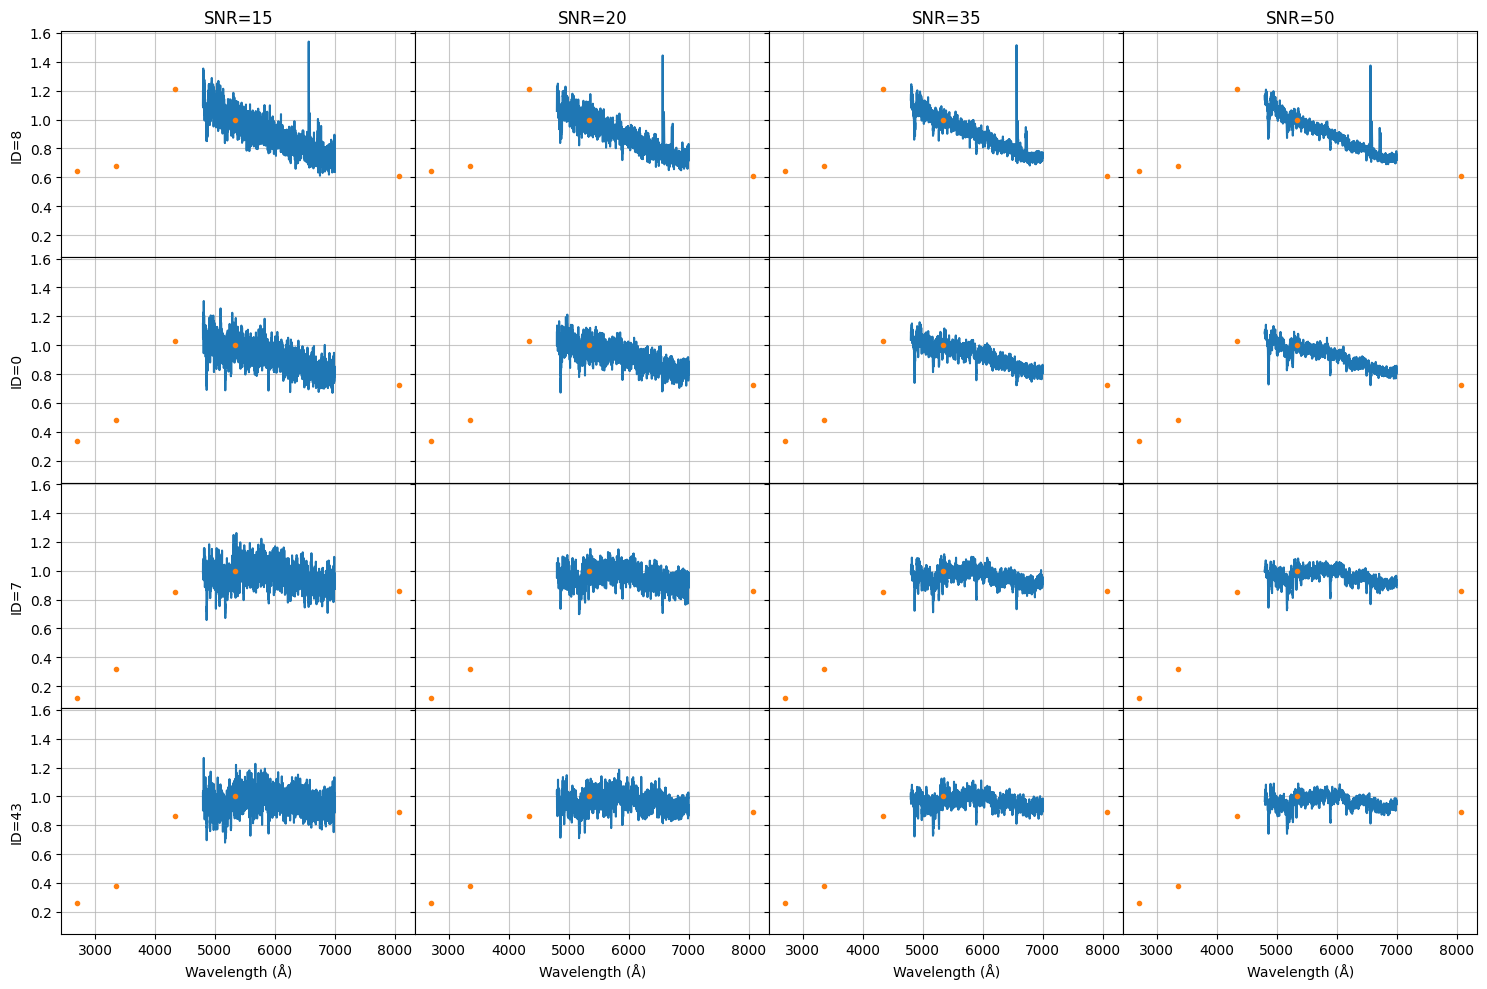

In [4]:
fig, ax = plt.subplots(nrows=elements_per_snr, ncols=len(snr), figsize=(15, 10), sharex=True, sharey=True)

for i in range(elements_per_snr):
    for j, snr_ in enumerate(snr):
        ax[i, j].plot(wavelength, in_data_by_snr[snr_]["spectra"][i, :])
        ax[i, j].plot(wavecen, in_data_by_snr[snr_]["photometry"][i, :], ".")

        # Add gridlines
        ax[i,j].grid(True, alpha=0.5, which="minor", ls=":")
        ax[i,j].grid(True, alpha=0.7, which="major")

for i in range(elements_per_snr):
    ax[i, 0].set_ylabel(f"ID={id_elements[i]}")
for j in range(len(snr)):
    ax[0, j].set_title(f"SNR={snr[j]}")
    ax[-1, j].set_xlabel("Wavelength (Å)")
    
plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()


## Processing the data through the model

To predict with the model, it is important to correctly feed the data into it. It is advisable to prepare each input pair (spectra, photometry) beforehand. Evaluating the model with keras introduces some overhead each time it calculates a prediction: processing the whole dataset in one pass is faster and more efficient than processing each datapoint individually.

When the model receives only one element, it requires additional confirmation of the dimensionally. We achieve this by reshaping the input vectors.

We will only evaluate the data with SNR=35 in this guide.

**IMPORTANT:** For a better fitting by the model, the metallicity values are scaled by a factor of 100 (This aids the Loss value by having the same order of magnitude). This needs to be undone.

In [5]:
snr_evaluate = 35

# Single input
i = 0
input_data_1 = [
    in_data_by_snr[snr_evaluate]["spectra"][i, :].reshape(1, -1),
    in_data_by_snr[snr_evaluate]["photometry"][i, :].reshape(1, -1)
]

prediction_1 = model.predict(input_data_1)

sfh_prediction_1, z_prediction_1 = prediction_1

z_prediction_1 /= z_multiplication_factor

2026-05-19 18:00:15.959025: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 0s 496ms/step


In [6]:
# All inputs
input_data_all = [
    in_data_by_snr[snr_evaluate]["spectra"],
    in_data_by_snr[snr_evaluate]["photometry"]
]

prediction = model.predict(input_data_all)

sfh_prediction, z_prediction = prediction
z_prediction /= z_multiplication_factor

1/1 [==============================] - 0s 298ms/step


## Plotting the results
The first element of the output of the `model.predict` method is the SFH and the second one is the metallicity evolution. The model returns the average SFR for each bin, so we will use the limits of the bin to plot these values.

We append a `0` at the end to match the end width of the last bin. Additionally, we use the keyword `where='post'` to correctly plot the ranges of the bins.

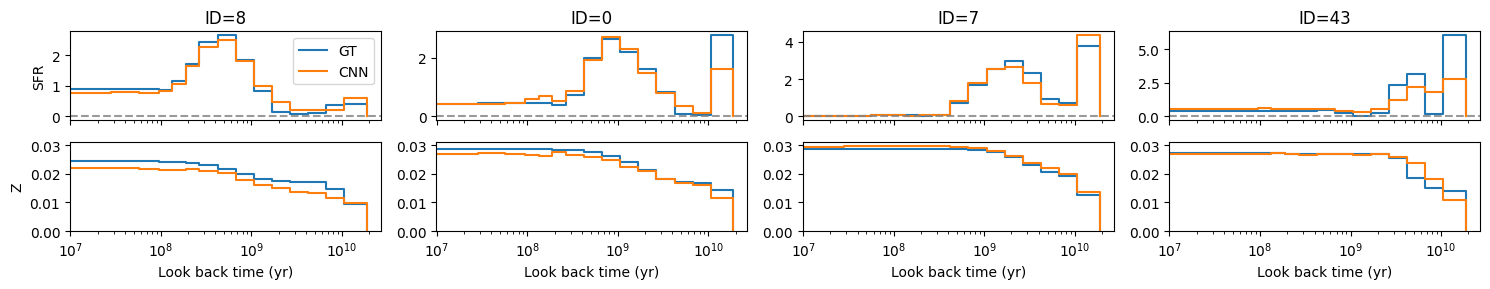

In [7]:
fig, ax = plt.subplots(ncols=elements_per_snr, nrows=2, figsize=(15, 3), sharex=True)


for i in range(elements_per_snr):
    label_sfr_i = np.append(label_by_snr[snr_evaluate]["sfh"][i, :], 0)
    pred_sfr_i = np.append(sfh_prediction[i, :], 0)
    ax[0, i].step(agebin, label_sfr_i, label="GT", where='post')
    ax[0, i].step(agebin, pred_sfr_i, label="CNN", where='post')
    ax[0, i].set_xscale("log")
    ax[0, i].axhline(y=0, ls="--", color="gray", alpha=0.8)

    label_z_i = np.append(label_by_snr[snr_evaluate]["z"][i, :], 0)
    pred_z_i = np.append(z_prediction[i, :], 0)
    ax[1, i].step(agebin, label_z_i, label="GT", where='post')
    ax[1, i].step(agebin, pred_z_i, label="CNN", where='post')
    ax[1, i].set_xscale("log")
    ax[1, i].set_yticks([0, 0.01, 0.02, 0.03])
    ax[1, i].set_ylim([0, 0.031])

    ax[0, i].set_title(f"ID={id_elements[i]}")
    ax[1, i].set_xlabel("Look back time (yr)")

ax[0, 0].legend()
ax[0, 0].set_ylabel("SFR")
ax[1, 0].set_ylabel("Z")
plt.tight_layout()
plt.show()